### Week 2: Department Classification Model

#### Objective

The goal of Week 2 was to build a machine learning model that automatically classifies citizen complaints into the correct government department.

---

#### Text Vectorization

Since machine learning models cannot process raw text, the complaint data was converted into numerical format using:

* **TF-IDF (Term Frequency-Inverse Document Frequency)**

This technique captures the importance of words relative to the dataset.

---

### Data Splitting

The dataset was divided into:

* Training set (80%)
* Testing set (20%)

This allows evaluation of model performance on unseen data.

---

### Model Development

A **Logistic Regression** model was used as the baseline classifier.

Enhancements:

* Increased iterations for better convergence
* Applied `class_weight='balanced'` to handle class imbalance

---

### Handling Class Imbalance

The dataset contained many departments with very few samples.

To improve performance:

* Rare classes were removed
* Balanced class weights were applied

---

### Outcome

By the end of Week 2:

* A working classification model was built
* Model performance was evaluated and improved
* The system can now automatically route complaints to departments

---

### Key Learnings

* Text data must be converted into numerical features
* Class imbalance significantly affects model performance
* Evaluation metrics beyond accuracy are crucial for understanding results

---


### Step 1: Loading and Cleaning the Dataset

The cleaned dataset is loaded from the processed folder.

Basic preprocessing steps are applied to ensure data quality:
- Removing missing values
- Eliminating empty text entries
- Converting text into string format

This prepares the dataset for machine learning.

In [1]:
import pandas as pd
df_clean = pd.read_csv('../data/processed/cleaned_data.csv')
# Clean data
df_clean = df_clean.dropna(subset=['complaint', 'department'])
df_clean = df_clean[df_clean['complaint'].str.strip() != ""]
df_clean['complaint'] = df_clean['complaint'].astype(str)
df_clean.head()

,complaint,department
0,railways railway board miscellaneous railw...,MORLY
1,xaxpxxxxxxx\tregarding cbcid inspection closed...,GOVUP
2,labour and employment pf withdrawal others...,MOLBR
3,labour and employment pension others name...,MOLBR
4,xaxpxxxxxxx\tregarding cbcid inspection closed...,GOVUP


###  Step 2: Handling Class Imbalance

The dataset contains many departments with very few samples.

To improve model performance, departments with extremely low frequency are removed.

This helps the model learn meaningful patterns instead of being biased toward dominant classes.

In [2]:
counts = df_clean['department'].value_counts()
valid_depts = counts[counts > 20].index
df_clean = df_clean[df_clean['department'].isin(valid_depts)]
df_clean['department'].value_counts()

department
PMOPG    46391
MOLBR    11423
DEABD     8613
GOVUP     6325
DOAAC     6324
         ...  
PRIW1       27
DDRDO       26
GOVGO       26
DOFZR       22
CGAT4       21
Name: count, Length: 137, dtype: int64

### Step 3: Sampling the Dataset

To speed up model training and experimentation, a subset of the dataset is selected.

This allows faster iteration while maintaining representative data for model building.

In [3]:
df_clean = df_clean.sample(5000, random_state=42)

### Step 4: Text Vectorization using TF-IDF

Text data is converted into numerical form using TF-IDF (Term Frequency-Inverse Document Frequency).

This technique assigns importance to words based on their frequency and relevance across the dataset.

The resulting vectors are used as input features for the machine learning model.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df_clean['complaint'])
y = df_clean['department']

###  Step 5: Splitting the Dataset

The dataset is divided into training and testing sets.

- Training set → used to train the model
- Testing set → used to evaluate performance

This ensures the model is tested on unseen data.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###  Step 6: Training the Classification Model

A Logistic Regression model is trained to classify complaints into departments.

To handle class imbalance, class weights are adjusted using:
- `class_weight = 'balanced'`

This improves the model’s ability to predict less frequent classes.

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300, class_weight='balanced')

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=300)

### Step 7: Model Evaluation

The model’s performance is evaluated using:

- Accuracy score
- Precision, Recall, and F1-score

These metrics provide insights into how well the model performs across different departments.

In [7]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.506
              precision    recall  f1-score   support

       AGPS5       0.00      0.00      0.00         0
       ARNPG       0.00      0.00      0.00         2
       CBODT       0.97      0.97      0.97        40
       CBOEC       0.17      1.00      0.29         1
       CGATP       0.43      1.00      0.60         3
       CGDAN       0.00      0.00      0.00         2
       CLC01       0.00      0.00      0.00         0
       CMASM       0.17      1.00      0.29         1
       DARPG       0.86      0.28      0.42        43
       DATOM       0.00      0.00      0.00         0
       DCOYA       0.05      0.50      0.08         2
       DDESW       0.14      0.17      0.15         6
       DDPRO       1.00      1.00      1.00         3
       DEABD       0.81      0.79      0.80        53
       DEAID       0.80      0.80      0.80         5
       DEAPR       0.20      1.00      0.33         1
       DEPOJ       0.30      0.38      0.33         8
       DHLT

C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", l

### Confusion Matrix

A confusion matrix is used to visualize the performance of the classification model.

It shows how many predictions were correct and where the model made errors across different departments.

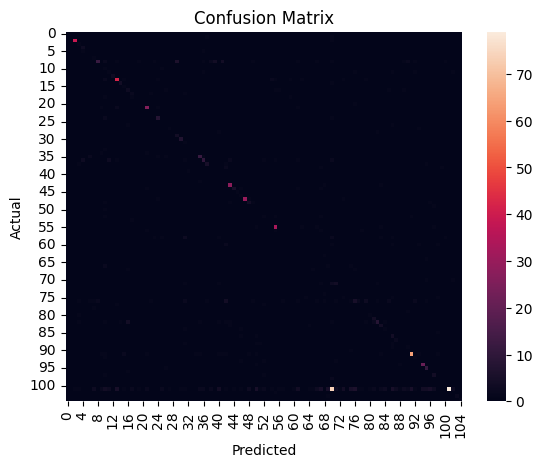

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("E:/grievance-ai-team/outputs/confusion_matrix.jpg")
plt.show()